In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from integral_functions.weight_functions import get_weights
from integral_functions.methods.inducing_points import get_discretizations, midpoint_to_disc
from numpy.typing import NDArray
from scipy.special import expit
from scipy.integrate import quad
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

from regmod.models.binomial import BinomialModel
from regmod.parameter import Parameter
from regmod.variable import Variable
# For more Cython info on the import statement, visit the link: https://stackoverflow.com/questions/7508803/how-do-i-import-function-from-pyx-file-in-python

from integral_functions.simulation.age_distribution import age_distribution
from integral_functions.simulation.death_rate import death_rate_function, expit_death_rate_function, func1, func2, func3
from integral_functions.simulation.sampling import sample_probability_of_death
from integral_functions.simulation.age_intervals import bounded_intervals_generator, int_bounded_intervals_generator
from integral_functions.simulation.integrate_functions import integrate_cov, integrate_denom

In [2]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

#### Uniform 1-year age groups

In [28]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df["obs"] = df.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args= {"c1": c1}
    ),
    axis=1,
)

# add grid_points: here I'm doing this on integers (and hence use arange). We can change
# this to np.linspace() for when we are not using integers. I'm just using integers because
# it felt like it would make more sense to me.
df["grid_points"] = df.apply(
    lambda row: np.arange(
        start=row.iloc[0] + 0.5,
        stop=row.iloc[1],
        step=1 # 1 here tells us the uniform grid size.
    ),
    axis=1
)

# Get population densities
df["pop_in_each_bin"] = df["sample_size"] / (df["age_end"] - df["age_start"])
df["pop_density"] = df["pop_in_each_bin"] / df["sample_size"]

# Get weights
df["weights"] = df.apply(
    lambda row: get_weights(
        lb=row.iloc[0],
        ub=row.iloc[1],
        population_density=row.iloc[-1],
        grid_points=row.iloc[4],
    ),
    axis=1
)

# Get function evaluations
df["function_evals1"] = df["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df["function_evals2"] = df["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df["function_evals3"] = df["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df["cov1"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals1),
    axis=1
)
df["cov2"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals2),
    axis=1
)
df["cov3"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals3),
    axis=1
)

# Here, we do not need the denom column because we already take into account
# the proportion of people in each bin

# Get constructed outcomes
df["outcomes"] = expit((c1 * df["cov1"] + c2 * df["cov2"] + c3 * df["cov3"]))

# df = df.loc[:, [x for x in df.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

In [29]:
df

,age_start,age_end,sample_size,obs,pop_density,cov1,cov2,cov3,outcomes
0,44,67,60,0.166667,0.043478,55.5,-7.436422,3124.250000,0.112077
1,47,67,54,0.092593,0.050000,57.0,-7.540120,3282.250000,0.129736
2,64,92,94,0.670213,0.035714,78.0,-8.819849,6149.250000,0.847079
3,9,37,62,0.016129,0.035714,23.0,-4.715893,594.250000,0.024538
4,21,42,35,0.000000,0.047619,31.5,-5.586001,1028.916667,0.021767
...,...,...,...,...,...,...,...,...,...
995,50,78,95,0.210526,0.035714,64.0,-7.983925,4161.250000,0.300315
996,53,79,88,0.352273,0.038462,66.0,-8.110828,4412.250000,0.367257
997,10,33,39,0.025641,0.043478,21.5,-4.578326,506.250000,0.024217
998,43,65,11,0.090909,0.045455,54.0,-7.335691,2956.250000,0.094828


In [30]:
model_discrete_1 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

In [31]:
model_discrete_1.fit()

In [32]:
model_discrete_1.opt_result.x

array([1.01039779e-01, 1.37658608e+00, 8.49219054e-04])

In [33]:
df_pred = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred["cov1"] = func1(df_pred["age_mid"])
df_pred["cov2"] = func2(df_pred["age_mid"])
df_pred["cov3"] = func3(df_pred["age_mid"])
df_pred = model_discrete_1.predict(df_pred)
df_pred["p_true"] = expit_death_rate_function(df_pred["age_mid"], c1=c1)

In [34]:
df_pred

,age_mid,cov1,cov2,cov3,p,p_true
0,0.00,0.00,-0.000000,0.0000,0.500000,0.500000
1,0.95,0.95,-0.974679,0.9025,0.223571,0.274443
2,1.90,1.90,-1.378405,3.6100,0.154145,0.202560
3,2.85,2.85,-1.688194,8.1225,0.116183,0.158219
4,3.80,3.80,-1.949359,14.4400,0.092185,0.127749
...,...,...,...,...,...,...
96,91.20,91.20,-9.549869,8317.4400,0.958191,0.990815
97,92.15,92.15,-9.599479,8491.6225,0.964687,0.992814
98,93.10,93.10,-9.648834,8667.6100,0.970259,0.994399
99,94.05,94.05,-9.697938,8845.4025,0.975021,0.995650


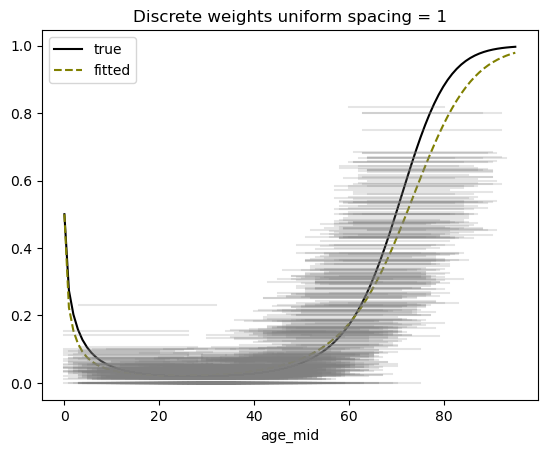

In [40]:
fig, ax = plt.subplots()
ax.plot(df_pred["age_mid"], df_pred["p_true"], color="k", label="true")
ax.plot(df_pred["age_mid"], df_pred["p"], color="olive", linestyle="--", label="fitted")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Discrete weights uniform spacing = 1")

for _, row in df.iterrows():
    ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

#### Continuous setting

In [36]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df_analytic = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df_analytic["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df_analytic["obs"] = df_analytic.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args= {"c1": c1}
    ),
    axis=1,
)

# add covariates
func_list = [func1, func2, func3]
for i, func in enumerate(func_list):
    df_analytic["cov" + str(i + 1)] = df_analytic.apply(
        lambda row: integrate_cov(
            func=func,
            density=age_distribution,
            age_start=row.iloc[0],
            age_end=row.iloc[1],
            age_mid=age_mid
        ),
        axis=1,
    )

# add denominators
df_analytic["denom"] = df_analytic.apply(
    lambda row: integrate_denom(
        density=age_distribution,
        age_start=row.iloc[0],
        age_end=row.iloc[1],
        age_mid=age_mid
    ),
    axis=1,
)

# Add outcomes -- the y_i's
df_analytic["cov1"] = df_analytic["cov1"] / df_analytic["denom"]
df_analytic["cov2"] = df_analytic["cov2"] / df_analytic["denom"]
df_analytic["cov3"] = df_analytic["cov3"] / df_analytic["denom"]
df_analytic["outcomes"] = expit((c1 * df_analytic["cov1"] + c2 * df_analytic["cov2"] + c3 * df_analytic["cov3"]))

In [37]:
df_analytic

,age_start,age_end,sample_size,obs,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,54.242932,-7.351654,2985.117748,498.300708,0.097730
1,47,67,54,0.092593,56.026660,-7.475428,3171.563412,414.015408,0.116321
2,64,92,94,0.670213,75.299857,-8.666320,5729.612287,283.057393,0.759387
3,9,37,62,0.016129,23.282353,-4.750777,603.666576,1042.469141,0.024097
4,21,42,35,0.000000,31.041881,-5.545434,999.245084,778.734937,0.021548
...,...,...,...,...,...,...,...,...,...
995,50,78,95,0.210526,61.894968,-7.851637,3892.791080,471.226104,0.236494
996,53,79,88,0.352273,64.120884,-7.994647,4165.007628,408.792608,0.299430
997,10,33,39,0.025641,21.827005,-4.616541,518.747051,868.173333,0.023826
998,43,65,11,0.090909,52.872907,-7.258651,2834.863397,496.876193,0.084207


In [38]:
model_cont = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df_analytic,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

model_cont.fit()

model_cont.opt_result.x

array([8.22648507e-02, 1.29620903e+00, 1.03733268e-03])

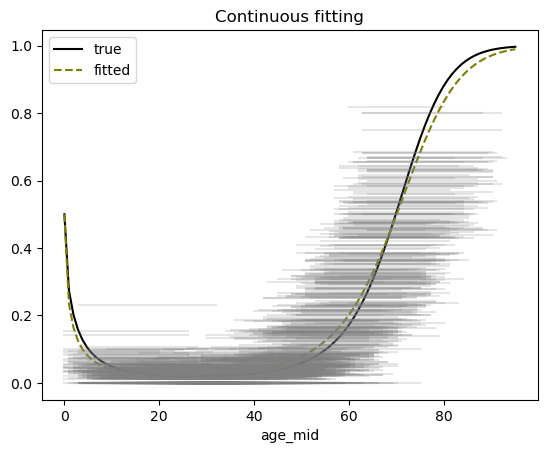

In [43]:
df_pred_cont = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred_cont["cov1"] = func1(df_pred_cont["age_mid"])
df_pred_cont["cov2"] = func2(df_pred_cont["age_mid"])
df_pred_cont["cov3"] = func3(df_pred_cont["age_mid"])
df_pred_cont = model_cont.predict(df_pred_cont)
df_pred_cont["p_true"] = expit_death_rate_function(df_pred_cont["age_mid"], c1=c1)

fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true")
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p"], color="olive", linestyle="--", label="fitted")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous fitting")

for _, row in df.iterrows():
    ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

Text(0.5, 1.0, 'Continuous v discrete fitting')

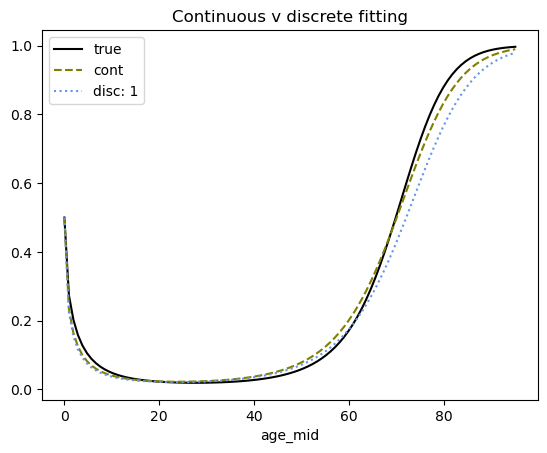

In [47]:
fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true")
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p"], color="olive", linestyle="--", label="cont")
ax.plot(df_pred["age_mid"], df_pred["p"], color="cornflowerblue", linestyle="dotted", label="disc: 1")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous v discrete fitting")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)